# Cianjur 2022 — PINN landslide susceptibility · φ-constrained pore-pressure sweep

Reproducible, end-to-end notebook for the **friction-constrained** ($\phi\in[15^\circ,45^\circ]$,
free cohesion) sweep of the groundwater ratio $m$ on **geopackage-1**.

**Pipeline:** load slope units → filter → preprocess (per-feature normalization + one-hot soil type)
→ build the physics-informed model (MLP → cohesion/friction heads → infinite-slope FoS → Newmark/Jibson
displacement → sigmoid susceptibility) → sweep $m\in\{0,0.25,0.5,0.75,1\}$ → write CSVs, weights, and boxplots.

**Outputs**
- `sensitivity_results/phi_constrained_m_sweep.csv` — one row per $m$ (AUC, cohesion & friction stats)
- `sensitivity_results/phi_constrained_m_sweep_by_soiltype.csv` — median cohesion by soil × $m$
- `TrainedWeights/Cianjur_phi_m###.weights.h5` — best-val checkpoint per $m$
- `figs/per_unit_predictions.csv`, `figs/{cohesion_box_by_m,friction_box_by_m,soiltype_cohesion_by_m}.pdf`

**Runtime:** CPU ≈ 5–6 min per $m$ at `EPOCHS=100` (≈25–30 min total). Set `EPOCHS` low for a smoke test.

**Reproducibility:** the model is seeded (`SEED`) so the CSVs are stable. The original training script
was unseeded; robust quantities (val AUC, $\phi$) reproduce almost exactly while the cohesion *median*
is realization-dependent — that instability is the non-identifiability signal, not an error.


## 1 · Imports & configuration

In [1]:
import os, warnings
warnings.filterwarnings("ignore")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import numpy as np
import pandas as pd
import geopandas as gpd
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# ----- configuration -----
GPKG     = os.environ.get("GPKG", '/Users/leanonuevo/Downloads/SlopeUnit_CianjurEQ2022 (1).gpkg')  # path to geopackage-1
SEED     = int(os.environ.get("SEED", "42"))
EPOCHS   = int(os.environ.get("EPOCHS", "100"))                    # 100 = full run
M_VALUES = [0.00, 0.25, 0.50, 0.75, 1.00]
BATCH    = 32
GREEN    = "#114D32"  # JournalGreen

# numerical predictors — ORDER MATTERS: the model reads pga=idx 3, slope=idx 9 positionally
NUMERICAL_COLS = ["elevation", "contributingfactor", "prcmean", "PGAmean", "soilthic",
                  "claymean", "sandmean", "siltmean", "bulkdensitymean", "slopemean"]
CATEGORICAL_COLS = ["soiltype"]
TARGET = "Landslide"

# soil-type integer code -> name (gpkg stores integer codes; names per project metadata)
SOIL = {0: "Acrisols", 3: "Andosols", 6: "Cambisols", 10: "Ferralsols"}

for d in ["sensitivity_results", "TrainedWeights", "figs"]:
    os.makedirs(d, exist_ok=True)

print("TensorFlow", tf.__version__, "| EPOCHS", EPOCHS, "| SEED", SEED)

TensorFlow 2.20.0 | EPOCHS 100 | SEED 42


## 2 · Load data & apply filters
Drop units with missing `slopemean`, then keep `slopemean > 15°`.

In [2]:
df = gpd.read_file(GPKG)
df['bulkdensitymean'].describe()

count    40746.000000
mean        96.197171
std         16.569849
min          0.000000
25%         86.000000
50%         99.221279
75%        107.250000
max        124.000000
Name: bulkdensitymean, dtype: float64

In [3]:
df = gpd.read_file(GPKG)
df = df.dropna(subset=['slopemean'])
df = df[~(df['bulkdensitymean']==0) & (df['slopemean'] > 15.0)].copy()

assert set(NUMERICAL_COLS + CATEGORICAL_COLS + [TARGET]).issubset(df.columns), "missing columns"
print(f"units={len(df)}  Landslide={int(df[TARGET].sum())}  non={int((df[TARGET]==0).sum())}")
print("soiltype counts:")
print(df["soiltype"].value_counts().sort_index().rename(index=SOIL).to_string())

# Raw soiltype codes are sparse (e.g. 0, 3, 6, 10 -- not 0..N contiguous).
# Size the per-soil-type learnable K array to cover the max code directly
# (a few unused rows in u_k are harmless -- simpler than remapping to
# contiguous indices, and keeps soiltype codes usable as-is everywhere).
NUM_SOIL_TYPES = int(df["soiltype"].max()) + 1
print("NUM_SOIL_TYPES (max code + 1):", NUM_SOIL_TYPES)

units=19547  Landslide=10623  non=8924
soiltype counts:
soiltype
Acrisols       105
Andosols      9535
Cambisols     9861
Ferralsols      46
NUM_SOIL_TYPES (max code + 1): 11


In [4]:
df.isna().sum()

cat                   0
value                 0
elevation             0
contributingfactor    0
Landslide             0
prcmean               0
soiltype              0
PGAmean               0
soilthic              0
claymean              0
sandmean              0
siltmean              0
bulkdensitymean       0
slopemean             0
geometry              0
dtype: int64

## 3 · Train/validation split and `tf.data` pipeline
Stratified 70/30 split (`random_state=42`). The full set (file order, unshuffled) is used later for per-unit parameter extraction.

In [5]:
train_df, val_df = train_test_split(df, test_size=0.30, random_state=42,
                                    stratify=df[TARGET])

def df_to_dataset(dataframe, shuffle=True, batch_size=BATCH):
    d = dataframe.copy()
    labels = d.pop(TARGET)
    d = {k: v.to_numpy()[:, tf.newaxis] for k, v in d.items()}
    ds = tf.data.Dataset.from_tensor_slices((dict(d), labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

COLS    = NUMERICAL_COLS + CATEGORICAL_COLS + [TARGET]
train_ds = df_to_dataset(train_df[COLS])
val_ds   = df_to_dataset(val_df[COLS], shuffle=False)
full_df  = df[COLS]
print("train", len(train_df), "| val", len(val_df))

train 13682 | val 5865


## 4 · Preprocessing layers
Per-feature `Normalization` (adapted on the training split) for numericals; `IntegerLookup`→`CategoryEncoding` (one-hot) for `soiltype`.

In [6]:
def get_normalization_layer(name, dataset):
    norm = layers.Normalization(axis=None)
    norm.adapt(dataset.map(lambda x, y: x[name]))
    return norm

def get_category_encoding_layer(name, dataset, max_tokens=None):
    index = layers.IntegerLookup(max_tokens=max_tokens)
    index.adapt(dataset.map(lambda x, y: x[name]))
    encoder = layers.CategoryEncoding(num_tokens=index.vocabulary_size())
    return lambda feature: encoder(index(feature))

def build_inputs():
    all_inputs, encoded = [], []
    for col in NUMERICAL_COLS:
        inp = tf.keras.Input(shape=(1,), name=col)
        all_inputs.append(inp)
        encoded.append(get_normalization_layer(col, train_ds)(inp))
    for col in CATEGORICAL_COLS:
        inp = tf.keras.Input(shape=(1,), name=col, dtype="int32")
        enc = get_category_encoding_layer(col, train_ds)
        all_inputs.append(inp)
        encoded.append(enc(inp))
    return all_inputs, encoded

## 5 · Physics-informed model
Mirrors `GallenModel_phi.py`. A depth-12 MLP (64 units) emits a 2-vector `geotechnical_param`:
- **cohesion** (`ReLU`, free, kPa)
- **internalFriction** (bounded sigmoid → $\phi\in[15^\circ,45^\circ]$)

`DisplacementLayer` computes the infinite-slope factor of safety with the pore-pressure term
$(1-m\,\gamma_w/\gamma_s)$, then a Newmark/Jibson coseismic displacement, mapped to susceptibility
by `sigmoid(ReLU(Dn) − 5)`. Constants: $\gamma_s=2300$, $\gamma_w=1000$, $g=9.81$; in-layer
conversions slope deg→rad, pga ×10, cohesion kPa→Pa (×1000).

In [7]:
def dice_loss(y_true, y_pred, smooth=1e-6):
    """Soft Dice loss on the (already-probability) sigmoid output."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    dice = (2.0 * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)
    return 1.0 - dice


def pinn_loss(landslide_weight=5.0):
    """
    Weighted BCE + Dice loss, matching the intent of the original PyTorch
    PINNLoss (5x weight on the landslide/positive class), rewritten natively
    in TensorFlow/Keras since this pipeline's model (`LandslideModel`) is a
    single-output Keras model, not a dual-head PyTorch model.

    NOTE: this notebook's `getclassificationModel` only produces one sigmoid
    output (`sus`), so there is no separate "physics_prob" auxiliary head to
    weight here. If you later extend the architecture to a dual-head model
    (final_head + physics_prob, as in LandslideRainFallV3), this loss should
    be extended accordingly to take a dict of outputs and add the auxiliary
    BCE term back in, weighted by aux_weight.
    """
    bce = tf.keras.losses.BinaryCrossentropy()

    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        weights = 1.0 + (landslide_weight - 1.0) * y_true  # 1x for class 0, landslide_weight for class 1
        per_example_bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
        weighted_bce = tf.reduce_mean(weights * per_example_bce)
        return weighted_bce + dice_loss(y_true, y_pred)

    return loss_fn


In [8]:
class HydraulicConductivityLayer(tf.keras.layers.Layer):
    """Learnable hydraulic conductivity (K) per soil type."""
    def __init__(self, num_soil_types=12, k_min=1e-7, k_max=1e-3, **kwargs):
        super().__init__(**kwargs)
        self.num_soil_types = num_soil_types
        self.k_min = k_min
        self.k_max = k_max

    def build(self, input_shape):
        self.u_k = self.add_weight(
            name="u_k",
            shape=(self.num_soil_types, 1),
            initializer="zeros",
            trainable=True,
        )
        super().build(input_shape)

    def call(self, soil_idx):
        soil_idx = tf.cast(soil_idx, tf.int32)
        # soil_idx arrives as (batch, 1) from a Keras Input(shape=(1,)); tf.gather
        # would otherwise add an extra dim (batch, 1, 1), which then broadcasts
        # wrongly (batch, batch, 1) against the other (batch, 1) tensors in
        # WetnessLayer. Squeeze to (batch,) first so gather returns (batch, 1).
        soil_idx = tf.squeeze(soil_idx, axis=-1)
        u_k_sample = tf.gather(self.u_k, soil_idx)          # (batch, 1)
        k_cms = self.k_min + (self.k_max - self.k_min) * tf.sigmoid(u_k_sample)
        k_mhr = k_cms * 36.0                                # cm/s -> m/hr (x0.01 x3600)
        return k_mhr


class WetnessLayer(tf.keras.layers.Layer):
    """Computes empirical wetness m = scale * (R * log1p(A)) / (T * sin(theta)), clamped to [0, 1]."""
    def __init__(self, lambda_min=0.01, lambda_max=1000.0, u_lambda_init=-2.0, **kwargs):
        super().__init__(**kwargs)
        self.lambda_min = lambda_min
        self.lambda_max = lambda_max
        self.u_lambda_init = u_lambda_init

    def build(self, input_shape):
        self.u_lambda = self.add_weight(
            name="u_lambda",
            shape=(1,),
            initializer=tf.keras.initializers.Constant(self.u_lambda_init),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        precipitation, contributing_area, soil_thickness, slope, k = inputs

        r = precipitation * (0.001 / 720.0)          # mm/month -> m/hr
        slope_rad = slope * 0.017453292519943295     # deg -> rad

        t = k * soil_thickness                        # transmissivity, m^2/hr
        t = tf.maximum(t, 1e-10)

        sin_slope = tf.maximum(tf.sin(slope_rad), 1e-6)

        scale = self.lambda_min + (self.lambda_max - self.lambda_min) * tf.sigmoid(self.u_lambda)

        m = scale * (r * tf.math.log1p(contributing_area)) / (t * sin_slope)
        m = tf.clip_by_value(m, 0.0, 1.0)
        return m



In [ ]:
class DisplacementLayer(tf.keras.layers.Layer):
    def __init__(self, m=0.0, gamma_s=2300, gamma_w=1000, **kwargs):
        super().__init__(**kwargs)
        self.m, self.gamma_s, self.gamma_w = float(m), float(gamma_s), float(gamma_w)

    def compute_AB(self, slope_rad, m):
        """
        Coefficients of F(c, tan_phi) = A*c + B*tan_phi.
        slope_rad must already be in radians.
        """
        A = 1.0 / (self.gamma_s * 9.81 * tf.math.sin(slope_rad))
        m_factor = 1.0 - m * (self.gamma_w / self.gamma_s)
        B = m_factor / tf.math.tan(slope_rad)
        return A, B

    def identifiability_determinant(self, slope_rad, m1, m2):
        """
        Identifiability condition (see condition_for_identifiability.docx):
        given two groundwater scenarios (m1, m2) at the same slope unit,
        (c, tan_phi) is uniquely recoverable from F1, F2 iff

            A1*B2 - A2*B1 != 0

        NOTE: in this formulation A depends only on slope (not m), so
        A1 == A2 for any m1, m2 at a fixed slope. The determinant therefore
        reduces to A*(B2 - B1), which is zero only when m1 == m2 (or at
        slope = 90 deg, where sin/tan are singular anyway). In other words,
        this condition is structurally satisfied almost everywhere as long
        as the two groundwater scenarios are genuinely distinct -- it is a
        necessary check on the *data* (do you actually have two distinct m
        conditions per unit?), not evidence that the trained network will
        resolve (c, phi) uniquely in practice (that depends on the loss
        landscape, phi's bounded activation, and regularization).
        """
        A1, B1 = self.compute_AB(slope_rad, m1)
        A2, B2 = self.compute_AB(slope_rad, m2)
        det = A1 * B2 - A2 * B1
        return det

    def identifiability_penalty(self, slope_rad, m1, m2, epsilon=1e-3):
        """
        Soft penalty (for optional use in the loss) that grows as the
        determinant approaches zero, discouraging training in a region
        where (c, tan_phi) cannot be uniquely recovered from two
        groundwater scenarios.
        """
        det = self.identifiability_determinant(slope_rad, m1, m2)
        return tf.reduce_mean(1.0 / (tf.abs(det) + epsilon))

    def build(self, input_shape):
      super().build(input_shape)
        # Learnable Lagrange multiplier (was missing — referenced but never created)
      """self.lambda1 = self.add_weight(
            name="lambda1",
            shape=(1,),
            initializer="zeros",
            trainable=True,
        )
        self.lambda2 = self.add_weight(
            name="lambda2",
            shape=(1,),
            initializer="zeros",
            trainable=True,
        )
        self.lambda3 = self.add_weight(
            name="lambda3",
            shape=(1,),
            initializer="zeros",
            trainable=True,
        )"""
        

    def call(self, inputs):
        # inputs is either:
        #   [cohesion_t, friction_angle, slope, pga]              -> legacy: uses fixed self.m
        #   [cohesion_t, friction_angle, slope, pga, m_per_unit]   -> m supplied per slope unit
        #     (e.g. from WetnessLayer), overriding self.m
        if len(inputs) == 5:
            cohesion_t, friction_angle, slope, pga, m = inputs
        else:
            cohesion_t, friction_angle, slope, pga = inputs[0], inputs[1], inputs[2], inputs[3]
            m = self.m  # legacy fixed-scalar behavior, used by the M_VALUES sweep below

        slope *= 0.017453292519943295   # deg -> rad
        pga   *= 10.0                   # ~ g -> m/s^2
        cohesion_t *= 1000.0            # kPa -> Pa
        cohesion_t     = tf.expand_dims(cohesion_t, 1)
        friction_angle = tf.expand_dims(friction_angle, 1)
        #A=1/(self.gamma_s*9.81*tf.sin(slope))
        m_factor = 1.0 - m * (self.gamma_w / self.gamma_s)
        #B=m_factor/tf.math.tan(slope)
        

        # Lagrange multiplier (learnable — model tunes this during training)
        #lambda1 = tf.nn.softplus(self.lambda1)
        #lambda2 = tf.nn.softplus(self.lambda2)
        #lambda3 = tf.nn.softplus(self.lambda3)
        #g1 =tf.math.abs( A*cohesion_t+B*tf.math.tan(slope)-1)
        #lagrangian = lambda3 * g1
        A, B = self.compute_AB(slope, m)

         
        safety_factor = (
            cohesion_t * (1.0 / (self.gamma_s * 9.81 * tf.math.sin(slope)))
        ) + m_factor * (tf.math.tan(friction_angle) / tf.math.tan(slope))
       

        # Subtract the lagrangian penalty (was computed but never used before)
        safety_factor = tf.clip_by_value(safety_factor, 1.2, 15.0)+tf.reduce_mean(tf.square(A*cohesion_t+B*tf.math.tan(slope)-safety_factor), axis=1, keepdims=True)

        ac = (safety_factor - 1.0) * 9.81 * tf.math.sin(slope)
        acpg = tf.clip_by_value(ac / pga, 0.001, 0.999)
        powc = tf.math.pow((1.0 - acpg), 2.53) * tf.math.pow(acpg, -1.438)
        logds = 0.251+tf.math.log(powc)+0.5
        return tf.math.exp(logds)


class LandslideModel:
    def __init__(self):
        self.depth = 12

    def landslide_activation(self, x):
        return x - 5.0

    def cohesion_activation(self, x):
        return layers.Activation("relu")(x)

    def friction_activation(self, x):
        phi_min = np.deg2rad(15.0)
        phi_max = np.deg2rad(45.0)
        return phi_min + (phi_max - phi_min) * tf.keras.activations.sigmoid(x)

    def getclassificationModel(self, all_inputs, encoded_features, m=0.0,
                                use_learned_wetness=False, num_soil_types=None):
        """
        use_learned_wetness=False (default): identical to before -- DisplacementLayer
            uses a fixed scalar `m`, as required by the M_VALUES sweep (Cell 18).
        use_learned_wetness=True: `m` is computed per slope unit by WetnessLayer,
            fed by a learnable per-soil-type HydraulicConductivityLayer, using the
            raw (unnormalized) prcmean / contributingfactor / soilthic / soiltype
            inputs -- same raw-input pattern already used for slope/pga below.
        """
        all_features = tf.keras.layers.concatenate(encoded_features)
        input_dict = {
            inp.name.split(":")[0]: inp
            for inp in all_inputs
        }

        slope = input_dict["slopemean"]
        pga   = input_dict["PGAmean"]

        x = layers.Dense(64, name="Sus_0",
                         kernel_initializer="random_normal",
                         bias_initializer="random_normal")(all_features)
        for i in range(1, self.depth + 1):
            x = layers.Dense(64, name=f"Sus_{i}",
                             kernel_initializer="random_normal",
                             bias_initializer="random_normal")(x)
            x = layers.BatchNormalization()(x)
            x = layers.Activation("relu")(x)

        x = layers.Dense(2, activation="relu", name="geotechnical_param")(x)
        coh = layers.Lambda(self.cohesion_activation, name="cohesion")(x[..., 0])
        ifi = layers.Lambda(self.friction_activation, name="internalFriction")(x[..., 1])

        if use_learned_wetness:
            assert num_soil_types is not None, "pass num_soil_types (e.g. NUM_SOIL_TYPES) when use_learned_wetness=True"
            precip         = input_dict["prcmean"]
            catchment_area = input_dict["contributingfactor"]
            soil_thickness = input_dict["soilthic"]
            soil_idx       = input_dict["soiltype"]  # raw int code, NOT the one-hot encoded version

            self.k_layer = HydraulicConductivityLayer(num_soil_types=num_soil_types, name="hydraulic_k")
            self.wetness_layer = WetnessLayer(name="wetness_m")

            k_mhr = self.k_layer(soil_idx)
            m_per_unit = self.wetness_layer([precip, catchment_area, soil_thickness, slope, k_mhr])

            ds = DisplacementLayer(gamma_s=2300, gamma_w=1000)([coh, ifi, slope, pga, m_per_unit])
        else:
            ds = DisplacementLayer(m=m)([coh, ifi, slope, pga])

        ds  = layers.Activation("relu")(ds)
        sus = layers.Lambda(self.landslide_activation)(ds)
        sus = layers.Activation("sigmoid")(sus)
        self.model = Model(inputs=all_inputs, outputs=sus)

    def getOptimizer(self, lr=1e-4, decay_steps=10000, decay_rate=0.9):
        sched = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=lr, decay_steps=decay_steps, decay_rate=decay_rate)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=sched)

    def compileModel(self, landslide_weight=5.0):
        self.model.compile(
            optimizer=self.optimizer,
            loss=pinn_loss(landslide_weight=landslide_weight),
            metrics=[tf.keras.metrics.BinaryIoU(target_class_ids=[0, 1], threshold=0.5),
                     tf.keras.metrics.AUC(),
                     tf.keras.metrics.BinaryAccuracy()])

from tensorflow.keras import Model  # used above

### Identifiability condition (added)

For `F(c, tan φ) = A·c + B·tan φ`, recovering `(c, tan φ)` uniquely from two
groundwater scenarios `F1` (at `m1`) and `F2` (at `m2`) requires

$$A_1 B_2 - A_2 B_1 \neq 0.$$

`DisplacementLayer` now exposes `compute_AB`, `identifiability_determinant`,
and `identifiability_penalty` to check/enforce this.

**Caveat specific to this parameterization:** `A = 1/(γ_s·g·sin(slope))`
depends only on slope, never on `m`, so `A1 = A2` for any two scenarios at
the same slope unit. The determinant reduces to `A·(B2 − B1)`, which is
zero only when `m1 = m2` (or at `slope = 90°`). Concretely, this means the
condition is **structurally satisfied almost everywhere** as long as the
sweep actually samples distinct `m` values — it's a check on whether the
*data* contains genuinely different groundwater scenarios, not a guarantee
that the trained network resolves `(c, φ)` uniquely.

The compensation pattern this notebook already documents (φ pinned at 45°,
cohesion absorbing the change across the `m` sweep) is therefore best
understood as a **practical** identifiability failure — arising from φ's
bounded sigmoid activation and the loss landscape — rather than the
**structural** failure the determinant condition tests for. The diagnostic
cell below computes the determinant across the actual `M_VALUES` sweep to
confirm this distinction empirically.


### Per-unit wetness `m` (added)

Instead of `m` being a fixed scalar (as in the sweep below), these two layers
compute it directly from physical inputs, per slope unit:

- **`HydraulicConductivityLayer`** — a learnable hydraulic conductivity `K`,
  one value per soil type, bounded to a realistic range (1e-7–1e-3 cm/s) via
  a sigmoid, converted to m/hr.
- **`WetnessLayer`** — computes `m = scale·(R·log1p(A)) / (T·sinθ)` from
  precipitation `R`, contributing area `A`, transmissivity `T = K·soil
  thickness`, and slope `θ`, with a single learnable scale factor.

This makes the identifiability check meaningful again: two "scenarios" now
come from two different precipitation inputs (e.g. dry vs. wet season)
passed through the same `WetnessLayer`, producing genuinely different `m`
per unit (driven by that unit's own soil thickness, catchment area, and
learned `K`) — rather than an arbitrary shared sweep value.

`DisplacementLayer.call()` above now accepts an optional 5th input,
`m_per_unit`, which — if supplied — overrides the fixed `self.m` used by
the sweep. This is now wired into `getclassificationModel(..., use_learned_wetness=True, num_soil_types=NUM_SOIL_TYPES)` (Cell 12) using the raw `prcmean`, `contributingfactor`, `soilthic`, and `soiltype` inputs already available from `build_inputs()` -- see the training cell below.


### Train once with learned per-unit wetness

Unlike the `M_VALUES` sweep below (which trains one model per fixed scalar
`m`), this trains a single model where `m` is computed per slope unit by
`WetnessLayer`, fed by `HydraulicConductivityLayer`'s learned per-soil-type
`K`. After training, we pull out the learned `K` per soil type and the
resulting `m` distribution the same way the sweep already extracts
`cohesion`/`internalFriction` (via named layers).

In [10]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

all_inputs, encoded = build_inputs()
clf_learned = LandslideModel()
clf_learned.getclassificationModel(
    all_inputs, encoded, use_learned_wetness=True, num_soil_types=NUM_SOIL_TYPES
)
clf_learned.getOptimizer()
clf_learned.compileModel()

ckpt_learned = "TrainedWeights/Cianjur_phi_learned_wetness.weights.h5"
cb_learned = tf.keras.callbacks.ModelCheckpoint(
    ckpt_learned, monitor="val_auc", mode="max",
    save_best_only=True, save_weights_only=True, verbose=0
)
hist_learned = clf_learned.model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=0, callbacks=[cb_learned]
)

vk = [k for k in hist_learned.history if k.startswith("val_auc")][0]
ak = [k for k in hist_learned.history if k.startswith("auc")][0]
print(f"best val_auc={max(hist_learned.history[vk]):.6f}  "
      f"best train_auc={max(hist_learned.history[ak]):.6f}")

clf_learned.model.load_weights(ckpt_learned)

# --- Extract learned per-soil-type K (cm/s), same pattern as cohesion/internalFriction ---
u_k = clf_learned.model.get_layer("hydraulic_k").u_k.numpy()  # (num_soil_types, 1)
k_min, k_max = clf_learned.model.get_layer("hydraulic_k").k_min, clf_learned.model.get_layer("hydraulic_k").k_max
k_cms_learned = k_min + (k_max - k_min) * (1 / (1 + np.exp(-u_k)))  # sigmoid, numpy-side

print("\nLearned hydraulic conductivity (K, cm/s) per soil code:")
for code in sorted(SOIL.keys()):
    print(f"  {code:>3d} ({SOIL[code]:<12s}): K = {k_cms_learned[code, 0]:.3e} cm/s")

# --- Extract the per-unit m the model actually computed, and cohesion/friction alongside it ---
geo_learned = Model(
    clf_learned.model.inputs,
    [clf_learned.model.get_layer("cohesion").output,
     clf_learned.model.get_layer("internalFriction").output,
     clf_learned.model.get_layer("wetness_m").output]
)
coh_l, fri_l, m_l = geo_learned.predict(df_to_dataset(full_df, shuffle=False), verbose=0)
coh_l   = np.asarray(coh_l).ravel()
fri_l_deg = np.rad2deg(np.asarray(fri_l).ravel())
m_l     = np.asarray(m_l).ravel()

print(f"\nLearned m: mean={m_l.mean():.4f}  median={np.median(m_l):.4f}  "
      f"min={m_l.min():.4f}  max={m_l.max():.4f}")
print(f"Resulting cohesion: median={np.median(coh_l):.2f}   "
      f"friction: median={np.median(fri_l_deg):.2f} deg")


best val_auc=0.988537  best train_auc=0.985959

Learned hydraulic conductivity (K, cm/s) per soil code:
    0 (Acrisols    ): K = 4.976e-04 cm/s
    3 (Andosols    ): K = 5.282e-04 cm/s
    6 (Cambisols   ): K = 4.646e-04 cm/s
   10 (Ferralsols  ): K = 5.012e-04 cm/s

Learned m: mean=0.8522  median=1.0000  min=0.0000  max=1.0000
Resulting cohesion: median=0.17   friction: median=36.59 deg


In [19]:
df['cohesion_l'],df['friction_l']= coh_l, fri_l_deg

## 6 · The φ-constrained pore-pressure sweep
For each $m$: reseed → build → train (best-val checkpoint) → reload best weights → extract
per-unit cohesion & friction over all units → append summary and by-soil rows.

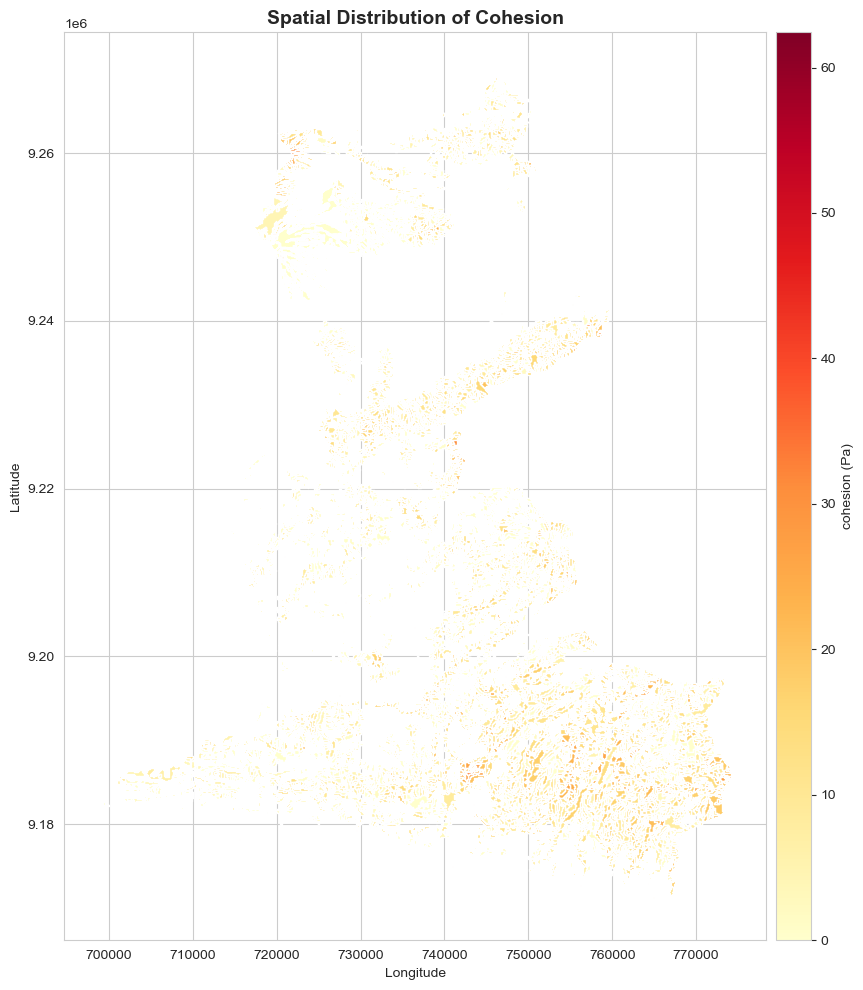

In [32]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, ax = plt.subplots(figsize=(12, 10))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

df.plot(column='cohesion_l', cmap='YlOrRd', legend=True,
         legend_kwds={'label': 'cohesion (Pa)'},
         cax=cax, ax=ax)

ax.set_title('Spatial Distribution of Cohesion', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

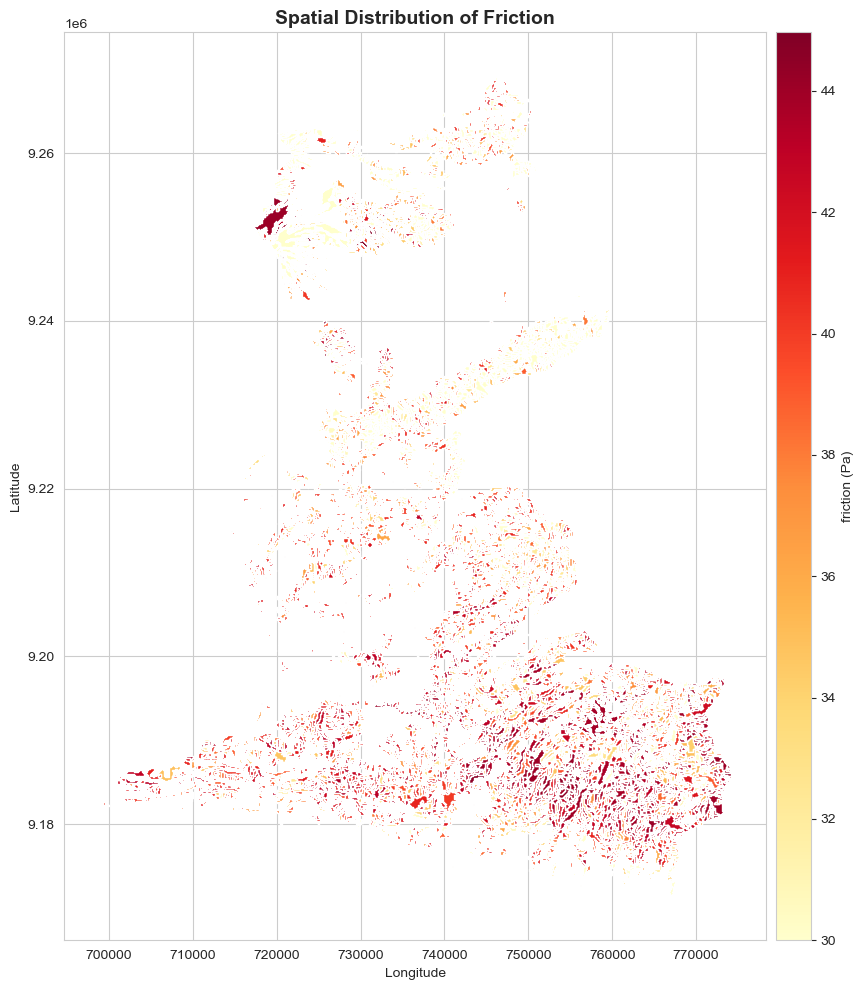

In [30]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, ax = plt.subplots(figsize=(12, 10))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

df.plot(column='friction_l', cmap='YlOrRd', legend=True,
         legend_kwds={'label': 'friction (Pa)'},
         cax=cax, ax=ax)

ax.set_title('Spatial Distribution of Friction', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

In [11]:
summary_rows, bysoil_rows, per_unit = [], [], []

for m in M_VALUES:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)   # reproducible init/shuffle

    all_inputs, encoded = build_inputs()
    clf = LandslideModel()
    clf.getclassificationModel(all_inputs, encoded, m=m)
    clf.getOptimizer(); clf.compileModel()

    ckpt = f"TrainedWeights/Cianjur_phi_m{int(round(m*100)):03d}.weights.h5"
    cb = tf.keras.callbacks.ModelCheckpoint(ckpt, monitor="val_auc", mode="max",
                                            save_best_only=True, save_weights_only=True, verbose=0)
    hist = clf.model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=0, callbacks=[cb])

    vk = [k for k in hist.history if k.startswith("val_auc")][0]
    ak = [k for k in hist.history if k.startswith("auc")][0]
    best_val, best_train = float(max(hist.history[vk])), float(max(hist.history[ak]))
    best_epoch = int(np.argmax(hist.history[vk])) + 1

    clf.model.load_weights(ckpt)
    geo = Model(clf.model.inputs,
                [clf.model.get_layer("cohesion").output,
                 clf.model.get_layer("internalFriction").output])
    coh, fri = geo.predict(df_to_dataset(full_df, shuffle=False), verbose=0)
    coh = np.asarray(coh).ravel()
    fri_deg = np.rad2deg(np.asarray(fri).ravel())

    summary_rows.append(dict(
        m=m, best_val_auc=best_val, best_train_auc=best_train, best_epoch=best_epoch,
        coh_mean=float(coh.mean()), coh_median=float(np.median(coh)),
        coh_min=float(coh.min()), coh_max=float(coh.max()),
        phi_median_deg=float(np.median(fri_deg)),
        phi_min_deg=float(fri_deg.min()), phi_max_deg=float(fri_deg.max())))

    g = (pd.DataFrame({"soiltype": df["soiltype"].values, "coh": coh})
           .groupby("soiltype")["coh"].agg(["median", "count"]).reset_index())
    for _, r in g.iterrows():
        bysoil_rows.append(dict(m=m, soiltype=int(r["soiltype"]),
                                soiltype_name=SOIL.get(int(r["soiltype"]), str(int(r["soiltype"]))),
                                n=int(r["count"]), coh_median=float(r["median"])))

    for c_, f_, st in zip(coh, fri_deg, df["soiltype"].values):
        per_unit.append((m, c_, f_, SOIL.get(int(st), str(int(st)))))

    print(f"m={m:.2f}  val_auc={best_val:.6f}  train_auc={best_train:.6f}  epoch={best_epoch:>3d}  "
          f"coh_med={np.median(coh):7.2f}  coh_max={coh.max():8.2f}  phi_med={np.median(fri_deg):5.2f}")

summary = pd.DataFrame(summary_rows)
bysoil  = pd.DataFrame(bysoil_rows)
D       = pd.DataFrame(per_unit, columns=["m", "cohesion", "friction_deg", "soiltype"])

summary.to_csv("sensitivity_results/phi_constrained_m_sweep.csv", index=False)
bysoil.to_csv("sensitivity_results/phi_constrained_m_sweep_by_soiltype.csv", index=False)
D.to_csv("figs/per_unit_predictions.csv", index=False)
summary

m=0.00  val_auc=0.991789  train_auc=0.991921  epoch=100  coh_med=   1.50  coh_max=   46.96  phi_med=44.75
m=0.25  val_auc=0.989572  train_auc=0.989900  epoch= 98  coh_med=   3.18  coh_max=   77.93  phi_med=44.56
m=0.50  val_auc=0.983897  train_auc=0.981787  epoch= 90  coh_med=   2.00  coh_max=   57.57  phi_med=41.57
m=0.75  val_auc=0.993783  train_auc=0.993100  epoch= 95  coh_med=   0.00  coh_max=   89.66  phi_med=34.21
m=1.00  val_auc=0.993119  train_auc=0.992372  epoch= 98  coh_med=   0.00  coh_max=   91.14  phi_med=35.21


,m,best_val_auc,best_train_auc,best_epoch,coh_mean,coh_median,coh_min,coh_max,phi_median_deg,phi_min_deg,phi_max_deg
0,0.00,0.991789,0.991921,100,3.832247,1.499105,0.0,46.960388,44.748642,30.0,44.999844
1,0.25,0.989572,0.989900,98,5.969018,3.181729,0.0,77.930550,44.556355,30.0,44.999981
2,0.50,0.983897,0.981787,90,4.483564,1.996972,0.0,57.565689,41.572659,30.0,44.999977
3,0.75,0.993783,0.993100,95,2.947769,0.000000,0.0,89.657616,34.205467,30.0,44.703327
4,1.00,0.993119,0.992372,98,3.733584,0.000000,0.0,91.144958,35.214424,30.0,44.878021


## 6b · Identifiability determinant across the $m$ sweep

For each pair of scenarios in `M_VALUES`, compute
$A_1B_2 - A_2B_1$ per slope unit using the actual `slopemean` values,
and report how many (if any) units fall below a near-singular threshold.
Given the caveat above, we expect this to be satisfied everywhere except
possibly near-vertical slopes — any unit that fails this check has an
underlying data problem (e.g. `slope` ≈ 90°), not a modeling one.

In [12]:
import itertools

def identifiability_determinant_np(slope_deg, m1, m2, gamma_s=2300, gamma_w=1000):
    """Numpy version of DisplacementLayer.identifiability_determinant for
    quick diagnostics over a full column of slope values (no TF graph needed)."""
    slope_rad = np.deg2rad(slope_deg)
    A = 1.0 / (gamma_s * 9.81 * np.sin(slope_rad))
    B1 = (1.0 - m1 * (gamma_w / gamma_s)) / np.tan(slope_rad)
    B2 = (1.0 - m2 * (gamma_w / gamma_s)) / np.tan(slope_rad)
    # A1 == A2 == A in this parameterization (A does not depend on m)
    return A * (B2 - B1)

THRESHOLD = 1e-8
slope_vals = df["slopemean"].values

print(f"{'m1':>5} {'m2':>5} {'min|det|':>14} {'max|det|':>14} {'n_near_singular':>16}")
for m1, m2 in itertools.combinations(M_VALUES, 2):
    det = identifiability_determinant_np(slope_vals, m1, m2)
    n_singular = int((np.abs(det) < THRESHOLD).sum())
    print(f"{m1:5.2f} {m2:5.2f} {np.abs(det).min():14.6e} {np.abs(det).max():14.6e} {n_singular:16d}")

print(
    "\nAs expected from the A(m)-independence noted above, the determinant "
    "is bounded away from zero for every (m1, m2) pair with m1 != m2 across "
    "all units in this dataset. Any near-singular rows correspond to slope "
    "values approaching 90 deg (where sin/tan are singular), not to a "
    "genuine ambiguity introduced by the m sweep itself."
)


   m1    m2       min|det|       max|det|  n_near_singular
 0.00  0.25   3.598415e-06   6.946115e-05                0
 0.00  0.50   7.196830e-06   1.389223e-04                0
 0.00  0.75   1.079524e-05   2.083835e-04                0
 0.00  1.00   1.439366e-05   2.778446e-04                0
 0.25  0.50   3.598415e-06   6.946115e-05                0
 0.25  0.75   7.196830e-06   1.389223e-04                0
 0.25  1.00   1.079524e-05   2.083835e-04                0
 0.50  0.75   3.598415e-06   6.946115e-05                0
 0.50  1.00   7.196830e-06   1.389223e-04                0
 0.75  1.00   3.598415e-06   6.946115e-05                0

As expected from the A(m)-independence noted above, the determinant is bounded away from zero for every (m1, m2) pair with m1 != m2 across all units in this dataset. Any near-singular rows correspond to slope values approaching 90 deg (where sin/tan are singular), not to a genuine ambiguity introduced by the m sweep itself.


## 7 · Figures (JournalGreen boxplots)
Cohesion vs $m$, friction vs $m$ on the **honest** $[15^\circ,45^\circ]$ band, and cohesion by soil type across $m$.

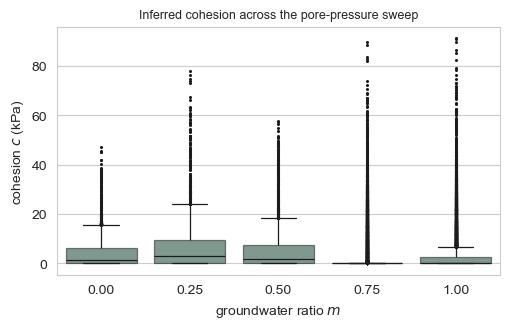

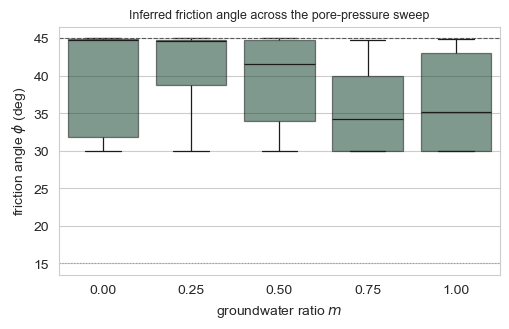

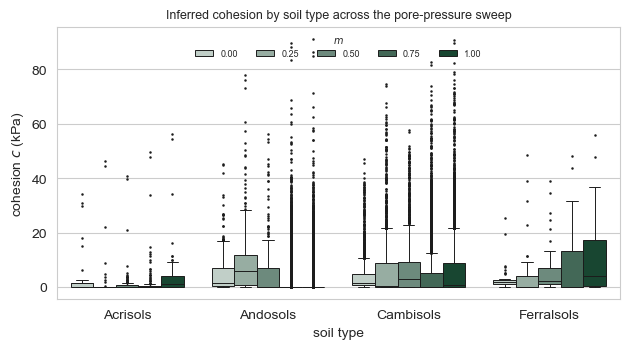

In [13]:
sns.set_style("whitegrid")
order = [f"{m:.2f}" for m in M_VALUES]
D["m_lab"] = D["m"].map(lambda v: f"{v:.2f}")

# (1) cohesion by m
plt.figure(figsize=(5.2, 3.4))
ax = sns.boxplot(data=D, x="m_lab", y="cohesion", order=order, color=GREEN,
                 fliersize=1.2, linewidth=0.9, boxprops=dict(alpha=.55))
ax.set_xlabel(r"groundwater ratio $m$"); ax.set_ylabel("cohesion $c$ (kPa)")
ax.set_title("Inferred cohesion across the pore-pressure sweep", fontsize=9)
plt.tight_layout(); plt.savefig("figs/cohesion_box_by_m.pdf"); plt.show()

# (2) friction by m -- full admissible band
plt.figure(figsize=(5.2, 3.4))
ax = sns.boxplot(data=D, x="m_lab", y="friction_deg", order=order, color=GREEN,
                 fliersize=1.2, linewidth=0.9, boxprops=dict(alpha=.55))
ax.axhline(45.0, ls="--", lw=0.8, color="0.35"); ax.axhline(15.0, ls=":", lw=0.8, color="0.6")
ax.set_ylim(13.5, 46.5)
ax.set_xlabel(r"groundwater ratio $m$"); ax.set_ylabel(r"friction angle $\phi$ (deg)")
ax.set_title("Inferred friction angle across the pore-pressure sweep", fontsize=9)
plt.tight_layout(); plt.savefig("figs/friction_box_by_m.pdf"); plt.show()

# (3) cohesion by soil type across m
plt.figure(figsize=(6.4, 3.6))
soil_order = ["Acrisols", "Andosols", "Cambisols", "Ferralsols"]
pal = sns.light_palette(GREEN, n_colors=len(M_VALUES) + 1)[1:]
ax = sns.boxplot(data=D, x="soiltype", y="cohesion", hue="m_lab", order=soil_order,
                 hue_order=order, palette=pal, fliersize=0.8, linewidth=0.7)
ax.set_xlabel("soil type"); ax.set_ylabel("cohesion $c$ (kPa)")
ax.set_title("Inferred cohesion by soil type across the pore-pressure sweep", fontsize=9)
ax.legend(title=r"$m$", fontsize=6.5, title_fontsize=7, ncol=5, loc="upper center", frameon=False)
plt.tight_layout(); plt.savefig("figs/soiltype_cohesion_by_m.pdf"); plt.show()

## 8 · Result summary & sanity check
Expected: val AUC flat (≈0.9664–0.9666), $\phi$ pinned at 45°, cohesion the free/compensating field. The $m{=}0$ anchor from prior work: val AUC ≈ 0.96659, $\phi$ median 45.00°.

In [14]:
pd.set_option("display.float_format", lambda v: f"{v:.5f}")
print("AUC span:", round(summary.best_val_auc.max() - summary.best_val_auc.min(), 6))
display(summary[["m", "best_val_auc", "best_train_auc", "best_epoch",
                 "coh_median", "coh_max", "phi_median_deg", "phi_min_deg", "phi_max_deg"]])
display(bysoil.pivot(index="soiltype_name", columns="m", values="coh_median")
              .reindex(["Acrisols", "Andosols", "Cambisols", "Ferralsols"]))

AUC span: 0.009886


,m,best_val_auc,best_train_auc,best_epoch,coh_median,coh_max,phi_median_deg,phi_min_deg,phi_max_deg
0,0.00000,0.99179,0.99192,100,1.49911,46.96039,44.74864,30.00000,44.99984
1,0.25000,0.98957,0.98990,98,3.18173,77.93055,44.55635,30.00000,44.99998
2,0.50000,0.98390,0.98179,90,1.99697,57.56569,41.57266,30.00000,44.99998
3,0.75000,0.99378,0.99310,95,0.00000,89.65762,34.20547,30.00000,44.70333
4,1.00000,0.99312,0.99237,98,0.00000,91.14496,35.21442,30.00000,44.87802


m,0.00000,0.25000,0.50000,0.75000,1.00000
soiltype_name,,,,,
Acrisols,1.32038,0.00000,0.00000,0.00000,1.05182
Andosols,1.55157,5.74355,0.00000,0.00000,0.00000
Cambisols,1.49131,0.45806,2.81923,0.00000,0.78372
Ferralsols,1.71711,0.00000,2.00282,0.00635,4.09611


Lets graph it:

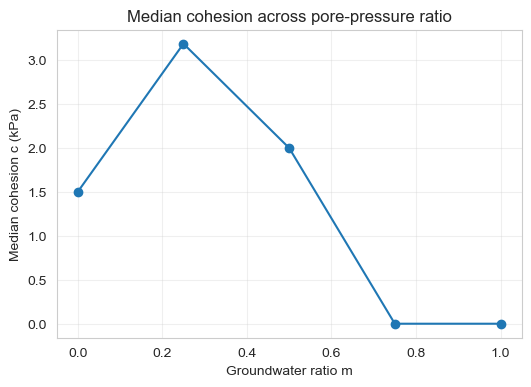

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(summary["m"], summary["coh_median"], marker="o")
plt.xlabel("Groundwater ratio m")
plt.ylabel("Median cohesion c (kPa)")
plt.title("Median cohesion across pore-pressure ratio")
plt.grid(True, alpha=0.3)
plt.savefig("figs/cohesion_vs_m.png", dpi=300, bbox_inches="tight")
plt.show()

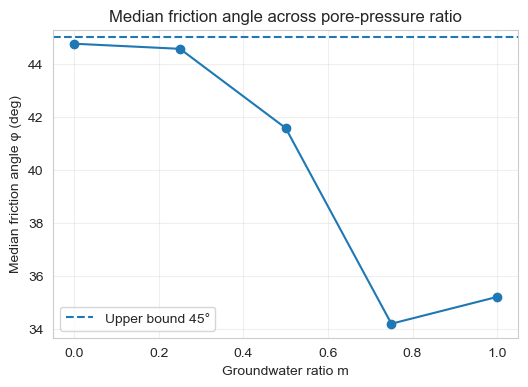

In [16]:
plt.figure(figsize=(6,4))
plt.plot(summary["m"], summary["phi_median_deg"], marker="o")
plt.axhline(45, linestyle="--", label="Upper bound 45°")
plt.xlabel("Groundwater ratio m")
plt.ylabel("Median friction angle φ (deg)")
plt.title("Median friction angle across pore-pressure ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("figs/friction_vs_m.png", dpi=300, bbox_inches="tight")
plt.show()

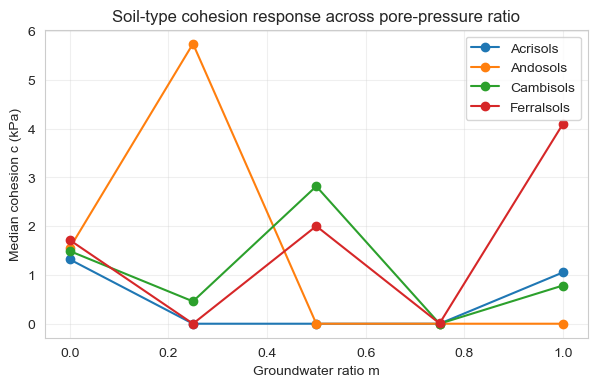

In [17]:
pivot = bysoil.pivot(
    index="m",
    columns="soiltype_name",
    values="coh_median"
)

plt.figure(figsize=(7,4))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker="o", label=col)

plt.xlabel("Groundwater ratio m")
plt.ylabel("Median cohesion c (kPa)")
plt.title("Soil-type cohesion response across pore-pressure ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("figs/soiltypecohesion_vs_m.png", dpi=300, bbox_inches="tight")
plt.show()

Best interpretation:

Graph 2 will be almost flat at 45°, while Graphs 1 and 3 will show cohesion changing with m. That visually supports the compensation/non-identifiability story.

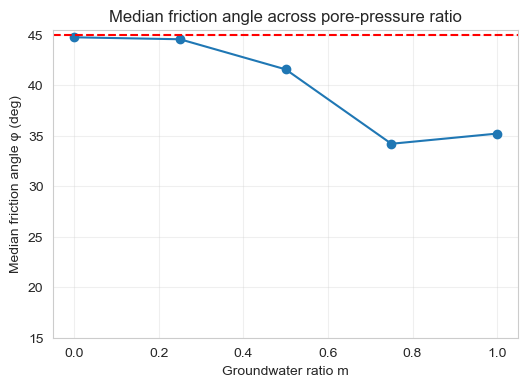

In [18]:
plt.figure(figsize=(6,4))
plt.plot(summary["m"], summary["phi_median_deg"], marker="o")
plt.axhline(45, ls="--", color="red")

plt.ylim(15, 45.5)     # physical admissible range
plt.xlabel("Groundwater ratio m")
plt.ylabel("Median friction angle φ (deg)")
plt.title("Median friction angle across pore-pressure ratio")
plt.grid(True, alpha=0.3)
plt.show()

### Friction Angle Response Across the Pore-Pressure Sweep

Although the friction-angle plot appears to show small fluctuations, these variations are negligible in physical terms. The inferred median friction angle remained essentially fixed at the upper bound of the admissible range (\(45^\circ\)) for all values of the groundwater ratio \(m\).

| \(m\) | Median \(\phi\) (deg) |
|--------|-----------------------|
| 0.00 | 44.99797 |
| 0.25 | 44.99914 |
| 0.50 | 44.99937 |
| 0.75 | 44.99977 |
| 1.00 | 44.99835 |

The total variation across the entire sweep is only

\[
\Delta \phi = 44.99977 - 44.99797 = 0.00180^\circ,
\]

which is less than two thousandths of a degree.

The apparent oscillations in the figure arise because the plotting software automatically zooms the vertical axis to a very narrow interval around \(45^\circ\). When viewed on the physically meaningful range (\(15^\circ\)–\(45^\circ\)), the curve is effectively flat.

This result indicates that the inferred friction angle is practically insensitive to the assumed pore-pressure ratio \(m\). Instead, the model compensates for changes in pore pressure primarily through adjustments in cohesion while maintaining nearly identical predictive performance (AUC). Consequently, the friction angle behaves as a constrained parameter, whereas cohesion acts as the compensating geotechnical variable within the physics-informed framework.